## Score calculation based on QG and PD models

In [ ]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import display

DATASETS = ["CaseReportBench", "PHEE", "DiscourseEE", "MACCROBAT"]
QG_Models =  ["gpt-oss-120b", "qwen3-4b", 'qwen3-8B']
PD_Models = ["gpt-oss-120b", "qwen3-4b", 'qwen3-8B'] #["gpt-5-mini", "gpt-4.1-mini", "gpt-oss-120b", "qwen3-32b", "Qwen3-4B", 'Qwen3-8B'] # "gpt-5-mini", "gpt-4.1-mini", "gpt-oss-120b", "qwen3-32b", 


OUTPUTS_SC_DIR = "/dartfs/rc/home/j/f006f3j/lab/omar/LoQA/Outputs/sc"

# --- Schema baseline (qg == pd == model) ---
schema_records: list[dict] = []
for dataset in DATASETS:
    for model in PD_Models:
        path = (
            OUTPUTS_SC_DIR
            / dataset
            / f"schema-{model}-zs-v0-{dataset}-test-{model}-zs-v0.json"
        )

        relaxed_f1 = None
        if path.exists():
            with path.open("r") as f:
                data = json.load(f)
            relaxed_f1 = data.get("overall", {}).get("relaxed-match-f1")

        schema_records.append(
            {
                "dataset": dataset,
                "pd_model": model,
                "schema_relaxed_match_f1": relaxed_f1,
            }
        )

schema_long = pd.DataFrame.from_records(schema_records)
schema_table = schema_long.pivot_table(
    index="dataset",
    columns="pd_model",
    values="schema_relaxed_match_f1",
    aggfunc="first",
).reindex(index=DATASETS, columns=PD_Models)

# --- LoQA scores ---
scores: dict[str, dict[str, dict[str, float | None]]] = {
    dataset: {qg: {} for qg in QG_Models} for dataset in DATASETS
}

records: list[dict] = []
for dataset in DATASETS:
    for qg_model in QG_Models:
        for pd_model in PD_Models:
            path = (
                OUTPUTS_SC_DIR
                / dataset
                / f"loqa-{qg_model}-zs-v0-{dataset}-test-{pd_model}-zs-v0.json"
            )

            relaxed_f1 = None
            if path.exists():
                with path.open("r") as f:
                    data = json.load(f)
                relaxed_f1 = data.get("overall", {}).get("relaxed-match-f1")

            scores[dataset][qg_model][pd_model] = relaxed_f1
            records.append(
                {
                    "dataset": dataset,
                    "qg_model": qg_model,
                    "pd_model": pd_model,
                    "relaxed_match_f1": relaxed_f1,
                }
            )

long_df = pd.DataFrame.from_records(records).merge(
    schema_long, on=["dataset", "pd_model"], how="left"
)
long_df["delta_vs_schema"] = (
    long_df["relaxed_match_f1"] - long_df["schema_relaxed_match_f1"]
)

# Tables: rows=(dataset, qg_model), columns=pd_model
score_table = long_df.pivot_table(
    index=["dataset", "qg_model"],
    columns="pd_model",
    values="relaxed_match_f1",
    aggfunc="first",
).reindex(
    index=pd.MultiIndex.from_product(
        [DATASETS, QG_Models], names=["dataset", "qg_model"]
    ),
    columns=PD_Models,
)

# Add schema baseline as a column (baseline for the same model as qg_model)
# i.e., schema-{qg_model}-...-test-{qg_model}-...
schema_by_qg = schema_long.rename(
    columns={
        "pd_model": "qg_model",
        "schema_relaxed_match_f1": "schema_baseline",
    }
)
schema_baseline = schema_by_qg.set_index(["dataset", "qg_model"])["schema_baseline"]

score_table = score_table.copy()
score_table.insert(0, "schema_baseline", schema_baseline.reindex(score_table.index))

# Add gains
pd_cols = [c for c in score_table.columns if c in PD_Models]
score_table["best_pd_score"] = score_table[pd_cols].max(axis=1, skipna=True)
score_table["score_gain"] = score_table["best_pd_score"] - score_table["schema_baseline"]

# Ensure removed columns (if previously created)
score_table = score_table.drop(columns=["dataset_best_gain"], errors="ignore")
score_table.columns.name = None

# Schema: rows=pd_model, columns=dataset
display(schema_table.T.round(2))

# Table 2: one table per dataset (rows=pd_model, columns=schema_baseline + qg_models)
for dataset in DATASETS:
    print("-"*100)
    print(dataset)
    st_slice = score_table.loc[dataset]
    display_df = st_slice[PD_Models].T  # rows=pd_model, columns=qg_model
    display_df.index.name = "pd_model"
    # Use schema_table (dataset x pd_model) - score_table index is (dataset, qg_model), so PD-only models like Qwen3-4B-think are missing
    display_df.insert(0, "schema_baseline", [schema_table.loc[dataset, pd] for pd in PD_Models])
    display_df["best_qg_score"] = display_df[QG_Models].max(axis=1)
    display_df["score_gain"] = display_df["best_qg_score"] - display_df["schema_baseline"]
    display(display_df.round(2))



dataset,CaseReportBench,PHEE,DiscourseEE
pd_model,,,
Qwen3-4B,14.8,54.86,12.04
Qwen3-4B-think,NaN,NaN,NaN
Qwen3-8B,13.4,60.21,14.58
Qwen3-8B-think,NaN,NaN,NaN


----------------------------------------------------------------------------------------------------
CaseReportBench


qg_model,schema_baseline,gpt-5-mini,gpt-4.1-mini,gpt-oss-120b,qwen3-32b,Qwen3-4B,Qwen3-8B,best_qg_score,score_gain
pd_model,,,,,,,,,
Qwen3-4B,14.8,23.57,23.96,26.60,21.31,17.85,18.11,26.60,11.80
Qwen3-4B-think,NaN,26.88,27.42,29.35,21.04,17.82,18.39,29.35,NaN
Qwen3-8B,13.4,24.49,23.55,26.65,19.41,16.62,17.26,26.65,13.25
Qwen3-8B-think,NaN,22.60,23.06,23.18,16.28,12.38,12.95,23.18,NaN


----------------------------------------------------------------------------------------------------
PHEE


qg_model,schema_baseline,gpt-5-mini,gpt-4.1-mini,gpt-oss-120b,qwen3-32b,Qwen3-4B,Qwen3-8B,best_qg_score,score_gain
pd_model,,,,,,,,,
Qwen3-4B,54.86,63.60,60.72,64.31,58.78,44.20,42.51,64.31,9.45
Qwen3-4B-think,NaN,56.45,51.83,57.53,51.29,36.59,34.99,57.53,NaN
Qwen3-8B,60.21,69.18,66.40,69.07,62.85,47.18,44.27,69.18,8.97
Qwen3-8B-think,NaN,64.37,59.68,64.35,55.67,36.49,34.35,64.37,NaN


----------------------------------------------------------------------------------------------------
DiscourseEE


qg_model,schema_baseline,gpt-5-mini,gpt-4.1-mini,gpt-oss-120b,qwen3-32b,Qwen3-4B,Qwen3-8B,best_qg_score,score_gain
pd_model,,,,,,,,,
Qwen3-4B,12.04,17.03,14.30,17.10,10.91,9.33,8.99,17.10,5.06
Qwen3-4B-think,NaN,14.79,13.76,15.99,10.50,8.47,7.97,15.99,NaN
Qwen3-8B,14.58,20.61,17.62,21.59,14.13,12.15,11.76,21.59,7.01
Qwen3-8B-think,NaN,19.70,16.10,20.65,13.46,10.26,9.47,20.65,NaN


## Average Score Calculation
average score calculation to see whic QG model is better. 
gpt-oss—120b is a stronger prediction model than gpt-5-mini. Therefore, when gpt-oss—120b predictions score is not considered when it is a question generation (QG) model, it average score is unfairly penalized. Based on the observed scores, we select GPT-OSS-120B as the best-performing QG model.

In [6]:
# Calculate average score for each qg model for each dataset, excluding cases where pd model == qg model
QG_Models = ["gpt-5-mini", "gpt-4.1-mini", "gpt-oss-120b"]
average_scores = {}
for dataset in DATASETS:
    avg_for_dataset = {}
    for qg_model in QG_Models:
        vals = []
        for pd_model in PD_Models:
            # if pd_model == qg_model:
            #     continue  # Skip if pd_model and qg_model are the same
            #Get value if present in score_table, else skip
            try:
                val = score_table.loc[(dataset, qg_model), pd_model]
                # print(dataset, qg_model, pd_model, val)
                if pd.notna(val):
                    vals.append(val)
            except KeyError:
                continue  # Just skip if this combo doesn't exist
        if vals:
            avg_for_dataset[qg_model] = sum(vals) / len(vals)
        else:
            avg_for_dataset[qg_model] = float("nan")
        # print("-"*100)
        # print(dataset, qg_model, avg_for_dataset[qg_model])
        # print("-"*100)
    average_scores[dataset] = avg_for_dataset

# Create a DataFrame for easier viewing
avg_score_df = pd.DataFrame(average_scores).round(2)
display(avg_score_df)

,CaseReportBench,PHEE,DiscourseEE
gpt-5-mini,19.85,34.15,7.62
gpt-4.1-mini,22.00,40.36,7.72
gpt-oss-120b,23.36,41.34,10.04


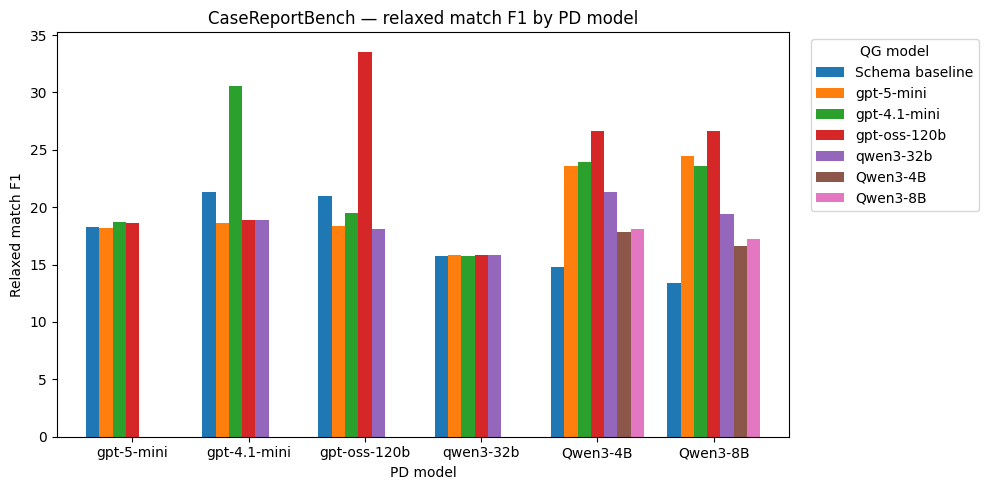

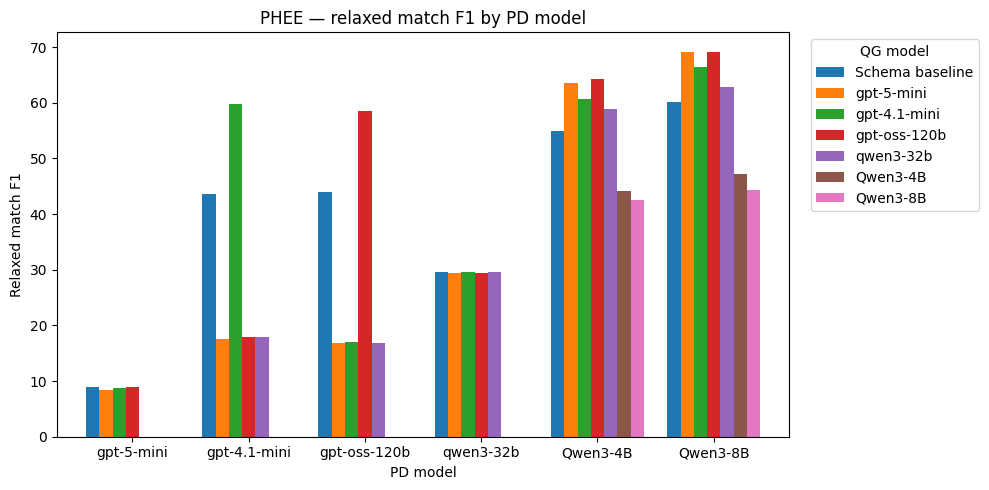

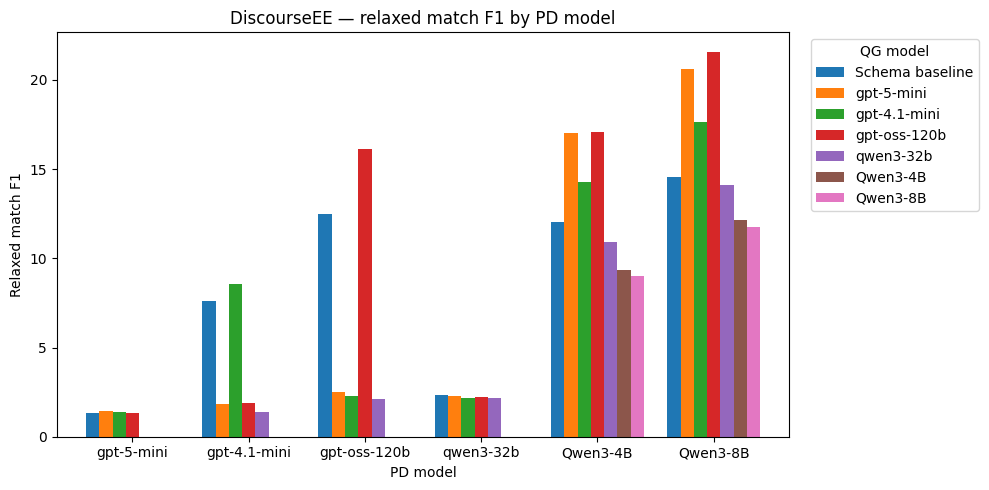

In [20]:
import matplotlib.pyplot as plt

# Bar plot per dataset: PD models on x-axis, bars = Schema baseline + QG models
for dataset in DATASETS:
    plot_data = []
    for pd_model in PD_Models:
        row = {"Schema baseline": score_table.loc[(dataset, pd_model), "schema_baseline"]}
        for qg_model in QG_Models:
            row[qg_model] = score_table.loc[(dataset, qg_model), pd_model]
        plot_data.append(row)
    df = pd.DataFrame(plot_data, index=PD_Models)
    ax = df.plot(kind="bar", figsize=(10, 5), width=0.8, rot=0)
    ax.set_title(f"{dataset} — relaxed match F1 by PD model")
    ax.set_ylabel("Relaxed match F1")
    ax.set_xlabel("PD model")
    ax.legend(title="QG model", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_ylim(0, None)

    plt.tight_layout()
    plt.show()